In [2]:
from typing import TypedDict , List

from langgraph.graph import StateGraph,START,END



In [3]:
class AgentState(TypedDict):  #our state schema
    num1: int
    num2: int
    ope : str
    result : int

In [4]:
def adder(state: AgentState)-> AgentState:
    """this node adds 2 numbers"""

    state["result"] = state["num1"] + state["num2"]

    return state

def subractor(state: AgentState)-> AgentState:
    """this node subtracts 2 numbers"""

    state["result"] = state["num1"] - state["num2"]

    return state

In [5]:
def decide_node(state: AgentState)-> AgentState:
    """ this node will decide which node to run next
    """

    if state["ope"] == "+":
        return "addition_operation"
    elif state["ope"] == "-":
        return "subtraction_operation"

In [6]:
graph = StateGraph(
    AgentState
)

 #passthrough func
graph.add_node("addition_node",adder)
graph.add_node("subtraction_node",subractor)
graph.add_node("router",lambda state:state)


graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decide_node,
    {    #   "edges" : node"
        "addition_operation":"addition_node",
        "subtraction_operation":"subtraction_node",
        
    }
)

graph.add_edge("addition_node",END)
graph.add_edge("subtraction_node",END)

app = graph.compile()


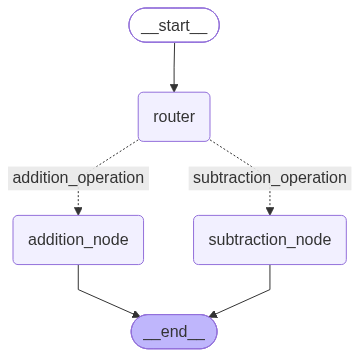

In [7]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
ans = AgentState(num1=2,num2=3,ope="-")
print(app.invoke(ans))

{'num1': 2, 'num2': 3, 'ope': '-', 'result': -1}


# exercise

In [9]:
class graph_schema(TypedDict):
    num1: int
    num2: int
    num3: int
    num4: int
    op1: str
    op2: str
    result1: int
    result2: int

In [25]:
def adder1(state: graph_schema)-> graph_schema:
    state["result1"]= state["num1"] + state["num2"]
    return state

def sub1(state: graph_schema)-> graph_schema:
    state["result1"]= state["num1"] - state["num2"]
    return state

def router1(state: graph_schema)-> graph_schema:
    if state["op1"] == "+":
        return "adding_operation"
    elif state["op1"] == "-":
        return "subtraction_operation"

In [26]:
def adder2(state: graph_schema)-> graph_schema:
    state["result2"]= state["num3"] + state["num4"]
    return state

def sub2(state: graph_schema)-> graph_schema:
    state["result2"]= state["num3"] - state["num4"]
    return state


def router2(state: graph_schema)-> graph_schema:
    if state["op2"] == "+":
        return "adding_operation2"
    elif state["op2"] == "-":
        return "subtraction_operation2"

In [27]:
graph = StateGraph(
    graph_schema
)

graph.add_node("router",lambda state:state)
graph.add_node("router2",lambda state:state)
graph.add_node("addingop1",adder1)
graph.add_node("subop1",sub1)
graph.add_node("addingop2",adder2)
graph.add_node("subop2",sub2)

graph.add_conditional_edges(
    "router",
    router1,
    {  #edges:node
        "adding_operation":"addingop1",
        "subtraction_operation":"subop1",
    }
)

graph.add_conditional_edges(
    "router2",
    router2,
    {  #edges:node
        "adding_operation2":"addingop2",
        "subtraction_operation2":"subop2",
    }
)

graph.add_edge(START,"router")

graph.add_edge("addingop1","router2")
graph.add_edge("subop1","router2")
graph.add_edge("addingop2",END)
graph.add_edge("subop2",END)

app = graph.compile()




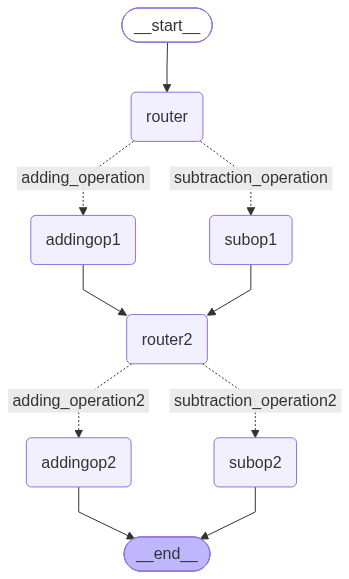

In [28]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [29]:
print(app.invoke(
    graph_schema(num1=2,num2=3,num3=4,num4=5,op1="+",op2="-")
))

{'num1': 2, 'num2': 3, 'num3': 4, 'num4': 5, 'op1': '+', 'op2': '-', 'result1': 5, 'result2': -1}
